<a href="https://colab.research.google.com/github/Yousra-khallou/Telecom-retention-system/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Notebook 01 — Data Exploration & Analysis**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_PATH = '/content/drive/MyDrive/mon-projet-retention'
os.chdir(BASE_PATH)
print(" Drive connecté !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive connecté !


## **Import Libraries**

In [ ]:
!pip install xgboost -q
print("✅ Librairies prêtes !")

✅ Librairies prêtes !


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print(" Imports Done")

 Imports Done


# **Data Retrieval**

In [ ]:
def load_telecom_data():
    return pd.read_csv('data/raw/Telco-Customer-Churn.csv')
telecom_data=load_telecom_data()
print(f" Shape : {telecom_data.shape}")
telecom_data.head()

 Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Take a Quick Look at the Data Structure**

In [ ]:
print("=" * 50)
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(f"Nombre de clients     : {telecom_data.shape[0]}")
print(f"Nombre de variables   : {telecom_data.shape[1]}")
print(f"Clients churners      : {telecom_data['Churn'].value_counts()['Yes']} ({telecom_data['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%)")
print(f"Clients fidèles       : {telecom_data['Churn'].value_counts()['No']} ({telecom_data['Churn'].value_counts(normalize=True)['No']*100:.1f}%)")
print()
print("TYPES DE COLONNES")
print(telecom_data.dtypes)

INFORMATIONS GÉNÉRALES
Nombre de clients     : 7043
Nombre de variables   : 21
Clients churners      : 1869 (26.5%)
Clients fidèles       : 5174 (73.5%)

TYPES DE COLONNES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
telecom_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The `customerID` column is removed from the dataset because it serves only as a unique identifier
and does not provide any meaningful information for predicting customer churn.

In [ ]:
telecom_data.drop('customerID', axis=1, inplace=True)

# **Data Type Correction**

In [ ]:
telecom_data["TotalCharges"].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


The `TotalCharges` column is stored as `object` type instead of numeric.
We convert it to numeric format for proper analysis.

In [ ]:
# Check current data type
print(f"Current dtype of TotalCharges: {telecom_data['TotalCharges'].dtype}")


# Convert to numeric (invalid values will become NaN)
telecom_data['TotalCharges'] = pd.to_numeric(telecom_data['TotalCharges'], errors='coerce')

# Verify conversion
print(f"New dtype of TotalCharges: {telecom_data['TotalCharges'].dtype}")
print(f"Missing values after conversion: {telecom_data['TotalCharges'].isna().sum()}")

Current dtype of TotalCharges: object
New dtype of TotalCharges: float64
Missing values after conversion: 11


In [ ]:
telecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Handling Missing Values

After converting `TotalCharges` to numeric, 11 missing values were identified,these rows are removed from the dataset to maintain data quality.

In [ ]:
# Remove rows with missing TotalCharges
telecom_data.dropna(subset=['TotalCharges'], inplace=True)
telecom_data.reset_index(drop=True, inplace=True)


# **Discover and Visualize the Data to Gain Insights**

Before building any model, we need to understand **how balanced our dataset is**.
This cell answers one key question: how many customers actually churned vs stayed?

We plot two complementary charts:
- A **countplot** (bar chart) showing the raw number of churned vs retained customers
- A **pie chart** showing the percentage breakdown

**What to look for:** If one class is much larger than the other, the dataset is
**imbalanced** — which means a naive model could just predict "stays" every time
and still get 73% accuracy without learning anything useful.
This is why we will later use `class_weight='balanced'` in our ML models.

/tmp/ipykernel_316/425954766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=telecom_data, ax=axes[0], palette=['#2ecc71', '#e74c3c'])


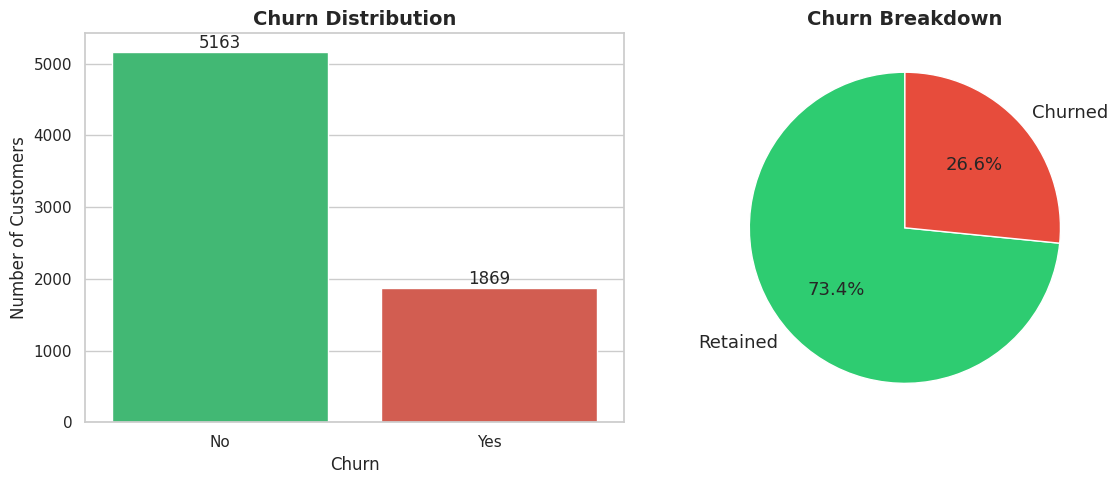

 Chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: countplot
sns.countplot(x='Churn', data=telecom_data, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Chart 2: pie chart
sizes = telecom_data['Churn'].value_counts()
axes[1].pie(sizes, labels=['Retained', 'Churned'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('Churn Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/churn_distribution.png', dpi=150)
plt.show()
print(" Chart saved")

Now we dig into **which customer profiles churn the most**.
We focus on two of the most business-relevant features:

- **Contract type**: are month-to-month customers more likely to leave than
  customers locked into 1 or 2-year contracts?
- **Tenure group**: do newer customers churn more than long-term ones?

We created a new column `tenure_group` using `pd.cut()` to group the 72 possible
tenure values into 4 readable intervals: 0–12, 12–24, 24–48, and 48–72 months.
This is for **visualization only** — the original `tenure` column is kept for modeling.

**What to look for:** A clear decreasing trend from left to right in both charts
confirms that contract length and customer loyalty are strong churn predictors.
These features will likely rank high in our model's feature importance.

/tmp/ipykernel_316/3342979578.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = telecom_data.groupby('tenure_group')['Churn_binary'].mean()


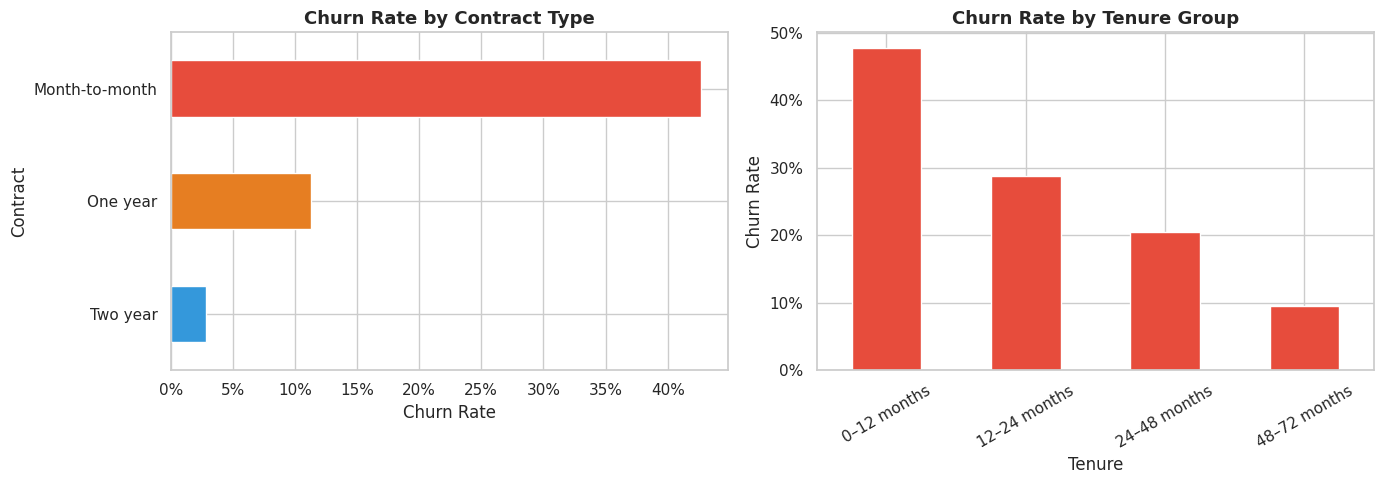

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type
contract_churn = telecom_data.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].sort_values().plot(kind='barh', ax=axes[0],
                                          color=['#3498db', '#e67e22', '#e74c3c'])
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Rate')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Tenure group
telecom_data['Churn_binary'] = (telecom_data['Churn'] == 'Yes').astype(int)
telecom_data['tenure_group'] = pd.cut(telecom_data['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0–12 months', '12–24 months', '24–48 months', '48–72 months'])
tenure_churn = telecom_data.groupby('tenure_group')['Churn_binary'].mean()
tenure_churn.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/processed/churn_by_contract_tenure.png', dpi=150)
plt.show()

Here we examine whether the **amount a customer pays** influences their decision to leave.

We plot two overlapping histograms (one per churn class) for:
- **MonthlyCharges**: what the customer pays each month
- **TotalCharges**: the cumulative amount paid since the beginning of the contract

The KDE (Kernel Density Estimation) curve(smooth line on top of the bars) makes it easier to compare
the overall shape of both distributions at a glance.

**What to look for:**
- For MonthlyCharges: if the red curve (churned) peaks at higher values than
  the green curve (retained), it means expensive plans drive churn.
- For TotalCharges: the interpretation is the opposite — a high total means
  the customer has been around for a long time, so they are less likely to churn.

**Key insight:** High monthly charges = churn risk. High total charges = loyal customer.
These are two different signals and both matter for our model.

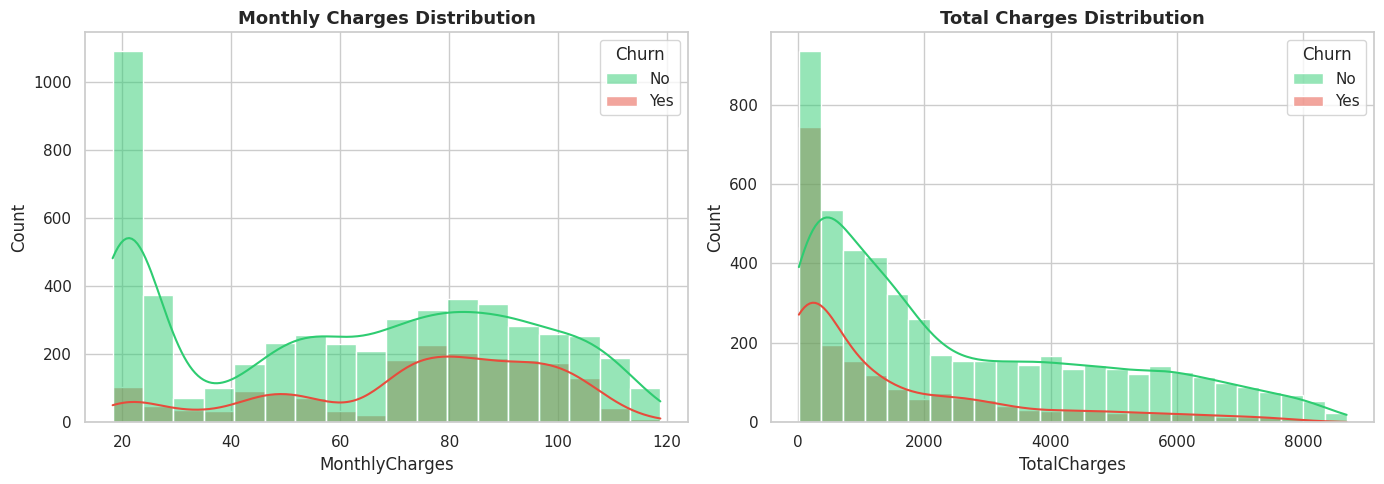

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Charges
sns.histplot(data=telecom_data, x='MonthlyCharges', hue='Churn',
             palette=['#2ecc71', '#e74c3c'], kde=True, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution', fontsize=13, fontweight='bold')

# Total Charges
sns.histplot(data=telecom_data, x='TotalCharges', hue='Churn',
             palette=['#2ecc71', '#e74c3c'], kde=True, ax=axes[1])
axes[1].set_title('Total Charges Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/churn_by_charges.png', dpi=150)
plt.show()

Before feeding features into a machine learning model, we need to understand
**how numerical variables relate to each other and to the churn target**.

A correlation heatmap shows a matrix of correlation coefficients:
- Values close to **+1** (dark red): strong positive relationship — when one goes up, the other goes up
- Values close to **-1** (dark blue): strong negative relationship — when one goes up, the other goes down
- Values close to **0**: no linear relationship

We use `np.triu` to mask the upper triangle since the matrix is symmetric
(correlation of A with B = correlation of B with A).

**What to look for:**
- Which features are most correlated with `Churn_binary`?
- Are any two features highly correlated with **each other**?
  (e.g. `tenure` and `TotalCharges` above 0.8 = multicollinearity)
  This means they carry redundant information — we may only need one of them in the model.

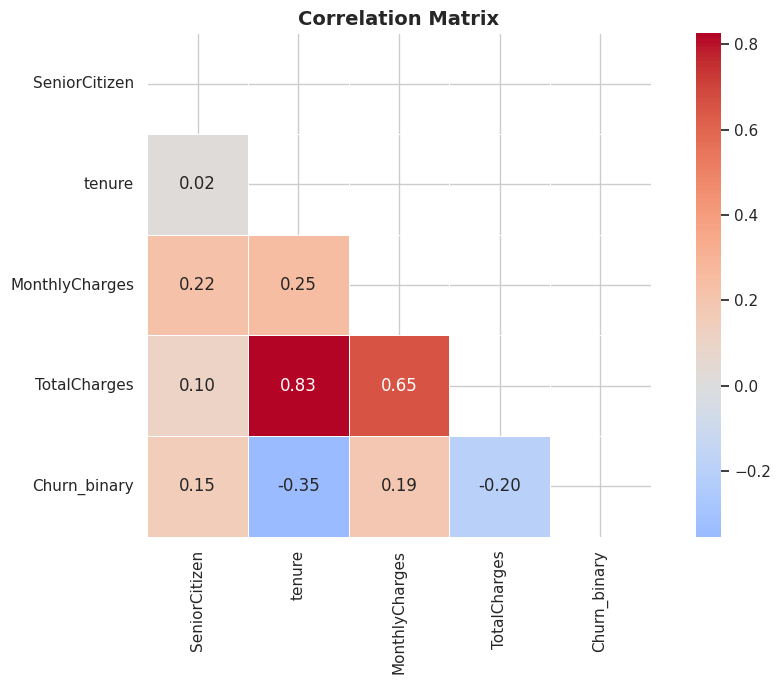

In [ ]:
# Select numeric columns only
num_cols = telecom_data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 7))
corr = telecom_data[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/correlation_matrix.png', dpi=150)
plt.show()

The dataset contains 9 optional services that customers can subscribe to.
This cell answers: **does having (or not having) a specific service affect churn?**

We loop through all 9 services and generate one bar chart per service,
showing the average churn rate for each subscription status
(Yes / No / No internet service).

This is done in a single `for` loop to avoid repeating the same code 9 times —
a standard best practice in data science notebooks.

**What to look for:**
- Services where "No" customers have a much higher churn rate than "Yes" customers
  are strong **retention levers** — offering them to at-risk customers is exactly
  what our recommendation system will do later.
- Services like `OnlineSecurity` and `TechSupport` typically show the largest gap,
  meaning they are the most protective against churn.



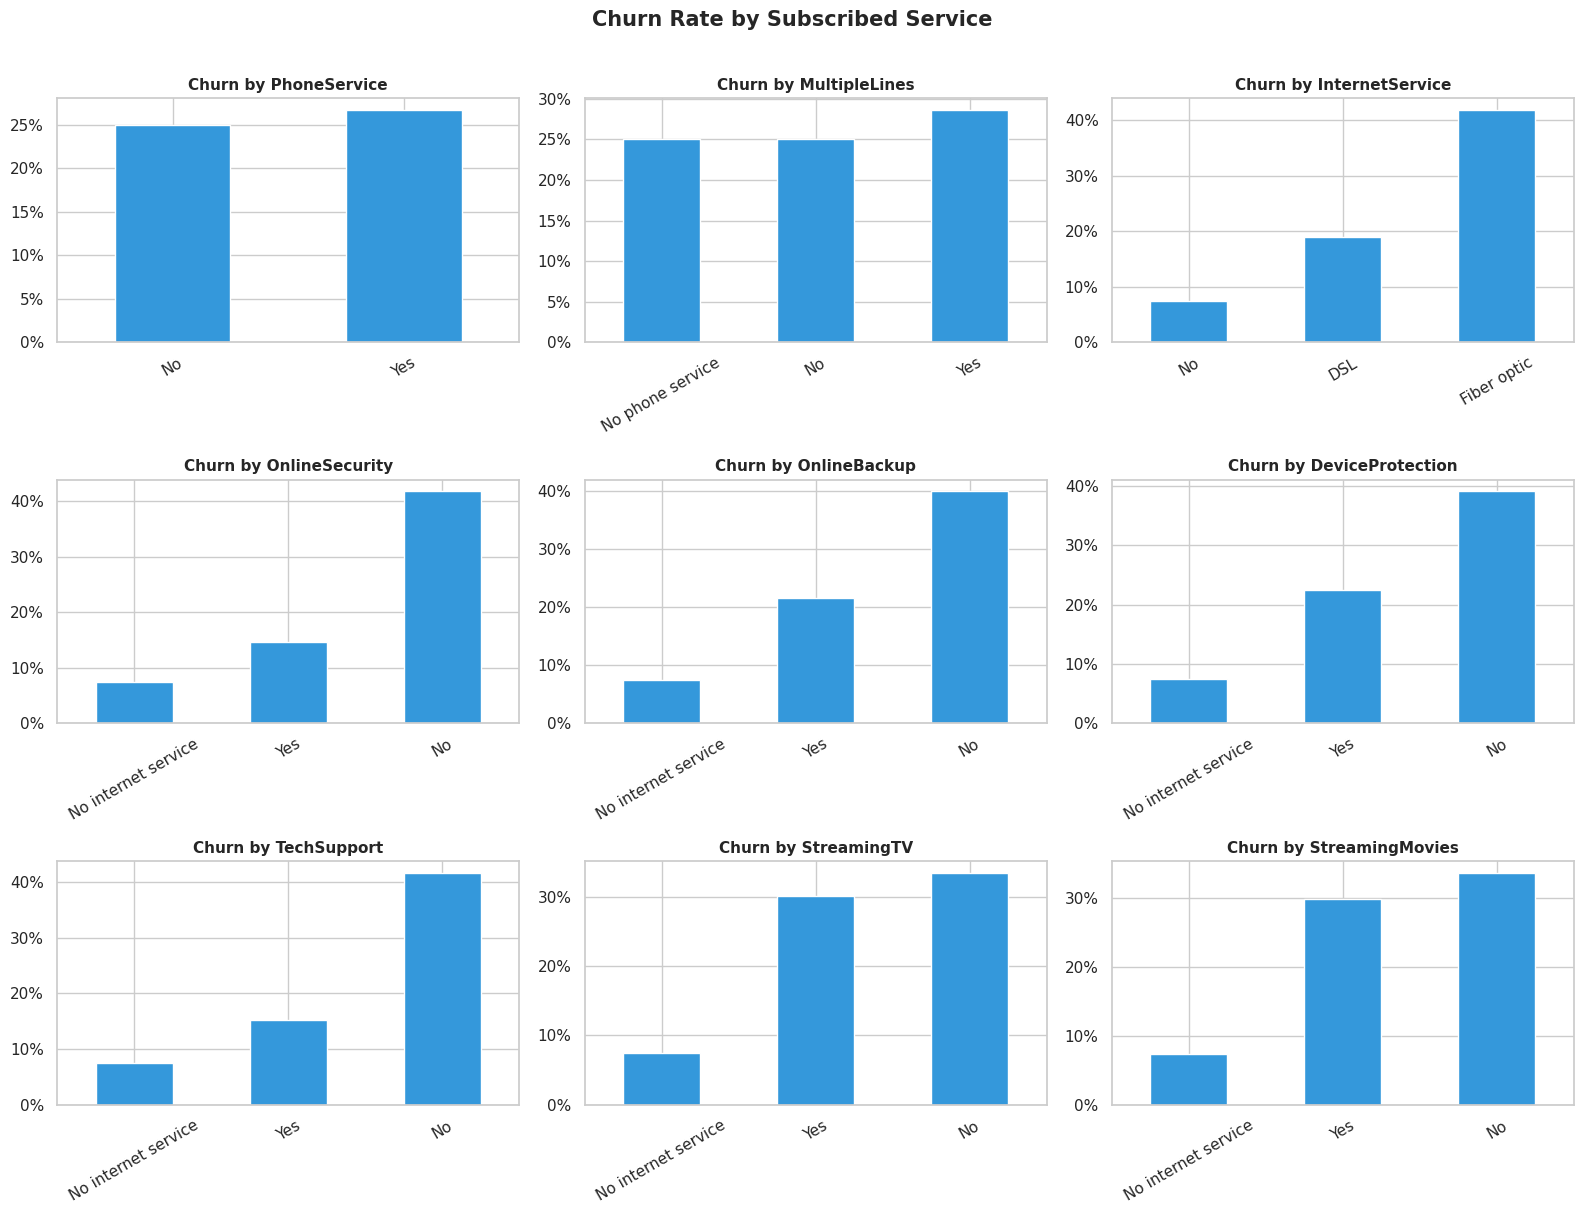

In [ ]:
services = ['PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, service in enumerate(services):
    churn_rate = telecom_data.groupby(service)['Churn_binary'].mean().sort_values()
    churn_rate.plot(kind='bar', ax=axes[i], color='#3498db', edgecolor='white')
    axes[i].set_title(f'Churn by {service}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Subscribed Service', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/processed/churn_by_services.png', dpi=150)
plt.show()

In [ ]:
# Encode target column
telecom_data['Churn_binary'] = (telecom_data['Churn'] == 'Yes').astype(int)

# Save
telecom_data.to_csv('data/processed/telco_clean.csv', index=False)
print(" Cleaned data saved to data/processed/telco_clean.csv")
print(f"   Final shape: {telecom_data.shape}")
print(telecom_data.head())

 Cleaned data saved to data/processed/telco_clean.csv
   Final shape: (7032, 22)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          

##  Notebook 1 — Complete

The dataset has been explored, cleaned, and saved to `data/processed/telco_clean.csv`.

### What we learned
- The dataset is **imbalanced**: ~26% churners vs 74% retained customers
- **Month-to-month contracts** have the highest churn rate (~43%)
- **New customers** (0–12 months tenure) are the most at risk (~50% churn)
- **High monthly charges** (60$–100$) are strongly associated with churn
- **No OnlineSecurity / TechSupport** = significantly higher churn rate
- `tenure` and `TotalCharges` are highly correlated (0.83) → potential multicollinearity

### What's next
In **Notebook 2**, we will use `telco_clean.csv` to build and evaluate
three churn prediction models: Logistic Regression, Random Forest, and XGBoost.
The best model will be saved to `models/churn_model.pkl` for use in the API.